<a href="https://colab.research.google.com/github/romellfudi/medium/blob/main/How_to_use_R_with_you_Data_storage_in_Google%C2%A0Drive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

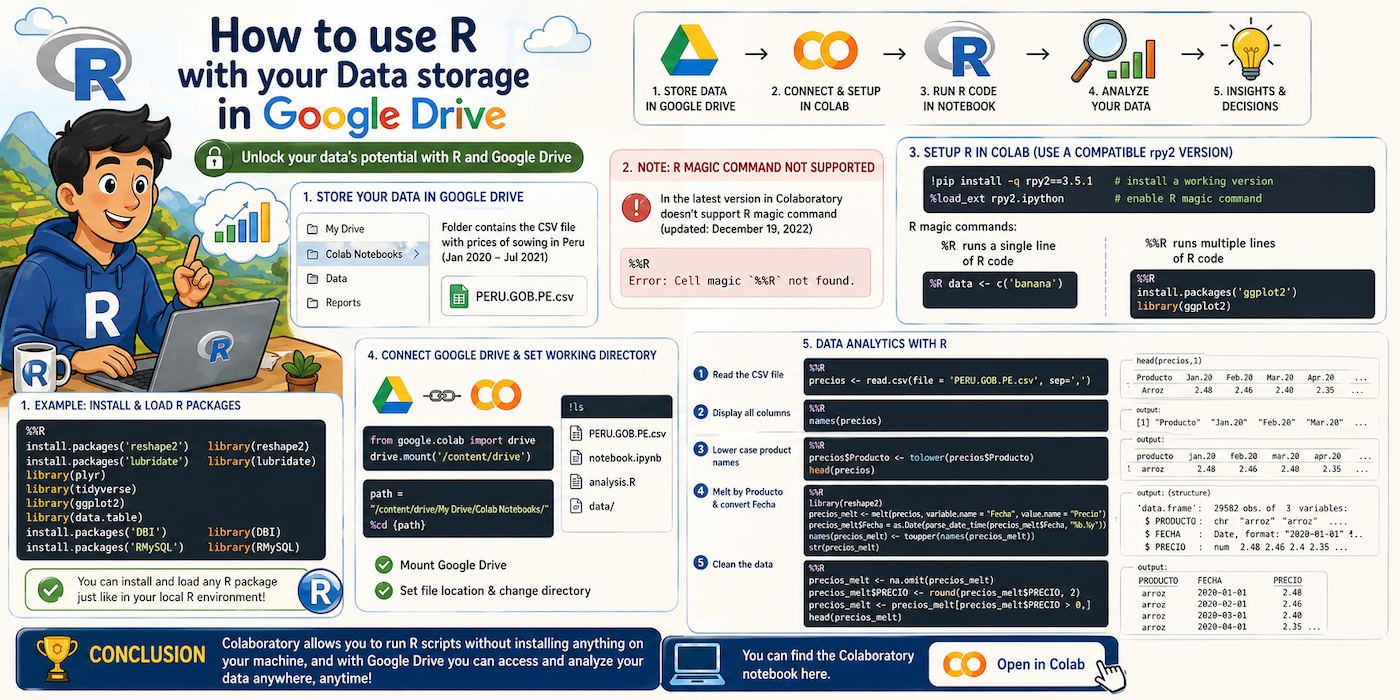

In [ ]:
!pip install -q rpy2==3.5.1

     |████████████████████████████████| 201 kB 29.0 MB/s 


In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%capture
%%R
install.packages('reshape2')
library(reshape2)
install.packages('lubridate')
library(lubridate)
library(plyr)
library(tidyverse)
library(ggplot2)
library(data.table)
install.packages('DBI')
library(DBI)
install.packages('RMySQL')
library(RMySQL)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path="/content/drive/My Drive/Colab Notebooks/"
%cd {path}

In [ ]:
%ls

In [ ]:
%%R
precios <- read.csv(file = 'PERU.GOB.PE.csv',sep=',')

In [ ]:
%%R
head(precios,1)

  Producto Jan.20 Feb.20 Mar.20 Apr.20 May.20 Jun.20 Jul.20 Aug.20 Sep.20
1      Aji   5.82   5.57   5.87   5.69   6.13   6.57   7.83   7.76   6.81
  Oct.20 Nov.20 Dec.20 Jan.21 Feb.21 Mar.21 Apr.21 May.21 Jun.21 Jul.21
1   6.37    6.7    7.9   7.27    7.1   7.73   7.45   6.96   6.69   7.51


In [ ]:
%%R
names(precios)

 [1] "Producto" "Jan.20"   "Feb.20"   "Mar.20"   "Apr.20"   "May.20"  
 [7] "Jun.20"   "Jul.20"   "Aug.20"   "Sep.20"   "Oct.20"   "Nov.20"  
[13] "Dec.20"   "Jan.21"   "Feb.21"   "Mar.21"   "Apr.21"   "May.21"  
[19] "Jun.21"   "Jul.21"  


In [ ]:
%%R
precios$Producto <- tolower(precios$Producto)
head(precios)

           Producto Jan.20 Feb.20 Mar.20 Apr.20 May.20 Jun.20 Jul.20 Aug.20
1               aji   5.82   5.57   5.87   5.69   6.13   6.57   7.83   7.76
2 aji amarillo seco  10.61  10.50  10.91  10.38  10.84  11.30  13.01  13.24
3     aji escabeche   2.41   2.71   2.60   1.87   1.74   1.53   1.99   1.82
4       aji montaña   3.03   3.04   2.84   2.80   2.98   2.92   4.80   4.01
5         aji panca   7.99   7.12   7.93   8.30  10.16  11.75  14.25  14.09
6       aji paprika   9.25   8.29   8.45   8.63   8.91   9.94  10.53  10.63
  Sep.20 Oct.20 Nov.20 Dec.20 Jan.21 Feb.21 Mar.21 Apr.21 May.21 Jun.21 Jul.21
1   6.81   6.37   6.70   7.90   7.27   7.10   7.73   7.45   6.96   6.69   7.51
2  11.73  10.49  11.75  13.45  12.92  12.73  12.57  12.52  12.03  11.76  13.03
3   2.42   3.24   3.53   3.05   2.95   2.05   1.42   1.83   3.51   2.94   3.25
4   3.72   3.66   3.01   3.32   2.97   3.62   5.79   4.51   2.47   2.65   2.79
5  10.53   8.68   9.84  14.36  13.46  12.60  13.10  13.08  12.64  12.68  

In [ ]:
%%R
library(reshape2)
precios_melt <- melt(precios,variable.name = "Fecha",value.name = "Precio")
precios_melt$Fecha = as.Date(parse_date_time(precios_melt$Fecha, "%b.%y"))

R[write to console]: Using Producto as id variables



In [ ]:
%%R
names(precios_melt) <- toupper(names(precios_melt))
str(precios_melt)

'data.frame':	1311 obs. of  3 variables:
 $ PRODUCTO: chr  "aji" "aji amarillo seco" "aji escabeche" "aji montaña" ...
 $ FECHA   : Date, format: "2020-01-01" "2020-01-01" ...
 $ PRECIO  : num  5.82 10.61 2.41 3.03 7.99 ...


In [ ]:
%%R
precios_melt <- na.omit(precios_melt)
precios_melt$PRECIO <- round(precios_melt$PRECIO,2)
precios_melt <- precios_melt[precios_melt$PRECIO>0,]
head(precios_melt)

           PRODUCTO      FECHA PRECIO
1               aji 2020-01-01   5.82
2 aji amarillo seco 2020-01-01  10.61
3     aji escabeche 2020-01-01   2.41
4       aji montaña 2020-01-01   3.03
5         aji panca 2020-01-01   7.99
6       aji paprika 2020-01-01   9.25
